# Classification DPE — Performant / Passable / Energivore
## Pipeline SVM (Support Vector Machine)

**Entree :** `data_for_processing_final.xlsx` — la colonne `etiquette_dpe` contient directement
les 3 groupes cibles.

**Objectif :** entrainer et evaluer un modele SVM sur les memes donnees que les autres notebooks
du pipeline (meme logique de split, de preprocesseur, de poids de classe), afin de comparer cette
approche a marge maximale avec la regression logistique et les modeles a base d'arbres.

**Specificites du SVM par rapport a la regression logistique :**
- Sensibilite forte a l'echelle des variables (mise a l'echelle indispensable).
- Choix du noyau (lineaire, polynomial, RBF) : determine la forme de la frontiere de decision.
- Hyperparametre C : compromis entre largeur de marge et tolerance aux erreurs (marge souple).
- Hyperparametre gamma (noyaux non lineaires) : controle la complexite locale de la frontiere.
- Notion de vecteurs de support : seules certaines observations determinent la frontiere.
- Cout algorithmique eleve sur de grands volumes de donnees (a la difference de la regression
  logistique), ce qui influence les choix faits dans ce notebook (sous-echantillonnage pour les
  comparaisons preliminaires, recours possible a LinearSVC).

**Pas de calibration** des probabilites dans ce notebook (volontairement laissee de cote).

**Plan du notebook :**
1. Imports et configuration
2. Chargement des donnees
3. Pretraitement
4. Split train / test
5. Pipeline et preprocesseur partage
6. Choix preliminaire du noyau
7. Optimisation des hyperparametres (Optuna)
8. Entrainement final du modele retenu
9. Evaluation du modele
   - 9.1 Courbes d'apprentissage (train vs validation)
   - 9.2 Matrice de confusion
   - 9.3 Rapport de classification (precision / rappel / F1 par classe)
   - 9.4 Courbes ROC et Precision-Rappel (one-vs-rest)
10. Diagnostics propres au SVM
   - 10.1 Vecteurs de support
   - 10.2 Courbes de validation sur C et gamma
   - 10.3 Heatmap C x gamma
   - 10.4 Visualisation de la frontiere de decision (projection 2D)
   - 10.5 Interpretation des coefficients (si noyau lineaire retenu)
11. Conclusion


## 1. Imports et configuration

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.preprocessing import RobustScaler, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.decomposition import PCA
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    learning_curve, validation_curve
)
from sklearn.metrics import (
    balanced_accuracy_score, accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve
)
from category_encoders import TargetEncoder

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")
%matplotlib inline


####################################### A PARAMETRER ################################

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Les 3 groupes metier, directement disponibles dans la colonne cible
TARGET = "etiquette_dpe"
GROUPS = ["Performant", "Passable", "Energivore"]

GROUP_COLORS = {
    "Performant": "#00923F",
    "Passable":   "#F2C12B",
    "Energivore": "#E6442E",
}

N_TRIALS = 25  # nombre d'essais Optuna pour la recherche d'hyperparametres

# Le SVM a noyau a un cout algorithmique eleve (entre O(n^2) et O(n^3) selon
# l'implementation). On utilise un sous-echantillon stratifie pour les etapes
# de comparaison preliminaire de noyaux et de recherche d'hyperparametres, puis
# le modele final est reentraine sur l'integralite du train set.
N_SAMPLE_OPTUNA = 8000

print("Imports OK")
print(f"  Cible : '{TARGET}' -> {GROUPS}")


Imports OK
  Cible : 'etiquette_dpe' -> ['Performant', 'Passable', 'Energivore']


## 2. Chargement des donnees

In [ ]:
FILE_PATH = "resources/data_for_processing_final.xlsx"

df = pd.read_excel(FILE_PATH)
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Valeurs manquantes totales : {df.isnull().sum().sum()}")

na_par_colonne = df.isnull().sum()
na_par_colonne = na_par_colonne[na_par_colonne > 0]
if len(na_par_colonne) > 0:
    print("\nColonnes concernees par des valeurs manquantes :")
    print(na_par_colonne)

vals = df[TARGET].unique()
print(f"\nValeurs uniques de '{TARGET}' : {sorted(vals)}")
print("Cible validee, les 3 groupes attendus sont presents")

print("\nDistribution de la cible :")
vc = df[TARGET].value_counts().reindex(GROUPS)
for grp, cnt in vc.items():
    pct = cnt / len(df) * 100
    bar = "#" * int(pct / 2)
    print(f"  {grp:<12} {cnt:6,}  ({pct:5.1f}%)  {bar}")

print(f"\nRatio de desequilibre : {vc.max() / vc.min():.1f}:1")


Dataset : 55,357 lignes x 25 colonnes
Valeurs manquantes totales : 9

Colonnes concernees par des valeurs manquantes :
configuration_installation_chauffage_n1    9
dtype: int64

Valeurs uniques de 'etiquette_dpe' : ['Energivore', 'Passable', 'Performant']
Cible validee, les 3 groupes attendus sont presents

Distribution de la cible :
  Performant    2,303  (  4.2%)  ##
  Passable     39,557  ( 71.5%)  ###################################
  Energivore   13,497  ( 24.4%)  ############

Ratio de desequilibre : 17.2:1


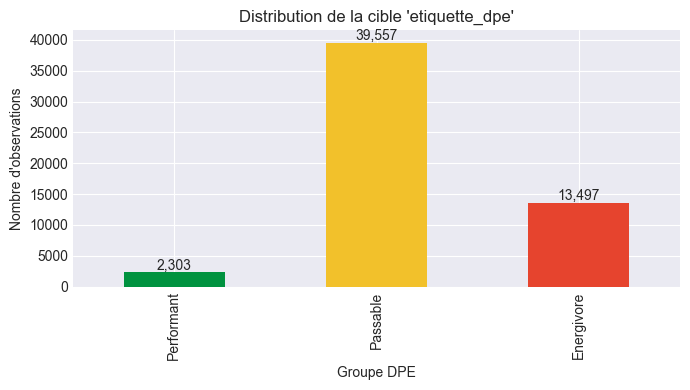

In [29]:
'''
Visualisation de la distribution de la cible. Sert a illustrer le desequilibre des
classes, deja constate ci-dessus, qui justifiera plus loin l'usage de poids de
classe pour le SVM (parametre class_weight) plutot que la seule exactitude comme
critere d'evaluation.
'''
fig, ax = plt.subplots(figsize=(7, 4))
vc.plot(kind="bar", color=[GROUP_COLORS[g] for g in vc.index], ax=ax)
ax.set_title("Distribution de la cible 'etiquette_dpe'")
ax.set_xlabel("Groupe DPE")
ax.set_ylabel("Nombre d'observations")
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()


## 3. Pretraitement des donnees

A la difference du fichier utilise dans le notebook de regression logistique, ce fichier
ne contient aucune colonne pre-encodee (suffixe `_enc`) : toutes les variables qualitatives
sont encore en texte brut et seront encodees par le `TargetEncoder` du preprocesseur partage
(section 5). Le fichier contient aussi un petit nombre de valeurs manquantes, traitees ici
par suppression des lignes concernees (volume negligeable).

In [ ]:
def drop_missing(df):
    '''
    Supprime les lignes contenant au moins une valeur manquante.

    Justification : le nombre de lignes concernees est tres faible au regard de la
    taille du dataset (quelques unites sur plus de 50 000 lignes), une imputation
    n'apporterait pas de gain notable et risquerait d'introduire un biais artificiel.
    '''
    n_before = len(df)
    df = df.dropna()
    n_after = len(df)
    print(f"Lignes supprimees pour valeurs manquantes : {n_before - n_after}")
    print(f"Dataset restant : {n_after:,} lignes")
    return df


def suppress_quasi_const(df):
    '''
    Supprime les colonnes quasi-constantes, c'est a dire les colonnes pour lesquelles
    une seule valeur represente plus de 95% des observations.

    Justification : une telle colonne n'apporte presque pas de variabilite au modele
    et se comporte essentiellement comme du bruit plutot que comme un signal utile.
    '''
    quasi_cst = [
        c for c in df.columns
        if c != TARGET
        and df[c].value_counts(normalize=True).iloc[0] > 0.95
    ]

    if quasi_cst:
        print(f"{'=' * 80}")
        print(f"Colonnes quasi-constantes supprimees ({len(quasi_cst)}) :")
        print(f"{'=' * 80}")
        for c in quasi_cst:
            top_val = df[c].value_counts(normalize=True).iloc[0]
            top_lab = df[c].value_counts().index[0]
            print(f"  {c:<50}  '{top_lab}' ({top_val:.1%})")
        df = df.drop(columns=quasi_cst)
    else:
        print(f"{'=' * 80}")
        print("Aucune colonne quasi-constante")
        print(f"{'=' * 80}")
    return df


def capping_outlier(df):
    '''
    Traitement des valeurs extremes :
    - hauteur_sous_plafond : ecretee (clip) a 6 metres, valeur jugee physiquement
      raisonnable pour un logement, au dela on considere une erreur de saisie.
    - colonnes a forte proportion de zeros (stockage ECS, production PV) : transformation
      log1p pour reduire l'asymetrie de la distribution sans perdre l'information des zeros.
    '''
    if "hauteur_sous_plafond" in df.columns:
        n = (df["hauteur_sous_plafond"] > 6.0).sum()
        df["hauteur_sous_plafond"] = df["hauteur_sous_plafond"].clip(upper=6.0)
        print(f"hauteur_sous_plafond clippee a 6m ({n} valeurs corrigees)")

    for col in ["volume_stockage_generateur_n1_ecs_n1",
                "production_electricite_pv_kwhep_par_an"]:
        if col in df.columns:
            df[col] = np.log1p(df[col])
            print(f"{col} -> log1p")

    print(f"\n{'=' * 80}")
    print(f"Dataset apres nettoyage : {df.shape[0]:,} x {df.shape[1]}")
    print(f"{'=' * 80}")
    return df


def encoding_ordinal(df):
    ordinal_vars = {
        'qualite_isolation_enveloppe':   ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_murs':        ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_menuiseries':  ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'qualite_isolation_plancher_bas': ['insuffisante', 'moyenne', 'bonne', 'très bonne'],
        'classe_inertie_batiment':        ['Légère', 'Moyenne', 'Lourde', 'Très lourde'],
        'periode_construction':           ['ancien', 'transition', 'moderne', 'recent', 'tres_recent'],
    }

    for col, order in ordinal_vars.items():
        if col not in df.columns:
            continue
        vals_in_data = set(df[col].dropna().unique())
        vals_in_order = set(order)
        unexpected = vals_in_data - vals_in_order
        if unexpected:
            print(f"⚠️  {col}: valeurs non prévues dans l'ordre → {unexpected}")
            for uv in unexpected:
                order.append(uv)

        mapping = {v: i for i, v in enumerate(order)}
        df[col + '_enc'] = df[col].map(mapping)
        n_nan = df[col + '_enc'].isnull().sum()
        print(f"{col} → encodé ({len(order)} niveaux, {n_nan} NaN)")

    # Suppression des colonnes d'origine, une fois encodées
    df = df.drop(columns=list(ordinal_vars.keys()))
    return df   # <-- la ligne qui manquait


In [ ]:
def classe_features(df):
    '''
    Classe les colonnes du dataframe en 4 groupes selon le traitement qu'elles
    recevront dans le preprocesseur :
    - ordinal_enc_cols  : deja encodees en amont (suffixe '_enc'), passees telles quelles.
    - binary_cols       : variables binaires, passees telles quelles.
    - quant_cols        : variables numeriques continues, a mettre a l'echelle.
    - qual_cols         : variables qualitatives nominales restantes, a encoder (TargetEncoder).
    '''
    ordinal_enc_cols = [c for c in df.columns if c.endswith("_enc")]

    binary_cols = [c for c in ["ventilation_posterieure_2012"] if c in df.columns]

    base_num = ["hauteur_sous_plafond", "volume_stockage_generateur_n1_ecs_n1",
                "production_electricite_pv_kwhep_par_an"]
    quant_cols = [c for c in base_num if c in df.columns]

    exclude = [TARGET] + ordinal_enc_cols + binary_cols + quant_cols
    qual_cols = [
        c for c in df.columns
        if c not in exclude
        and (df[c].dtype == object or str(df[c].dtype) == "str")
    ]

    passthrough_cols = ordinal_enc_cols + binary_cols
    all_features = quant_cols + qual_cols + passthrough_cols

    print(f"\n{'=' * 40} Features pour le modele {'=' * 40}")
    print(f"Features totales : {len(all_features)}")
    print(f"  Numeriques   ({len(quant_cols)}) : {quant_cols}")
    print(f"  Qualitatives ({len(qual_cols)})")
    print(f"  Passthrough  ({len(passthrough_cols)})")
    print(f"{'=' * 80}")

    return all_features, quant_cols, qual_cols, passthrough_cols


def preprocessing(df):
    '''Enchaine les 3 etapes de nettoyage / classement des colonnes.'''
    df_suppr_quasi_const = suppress_quasi_const(df)
    df_process = capping_outlier(df_suppr_quasi_const)
    df_process_ordinal = encoding_ordinal(df_process)
    all_features, quant_cols, qual_cols, passthrough_cols = classe_features(df_process_ordinal)
    return df_process_ordinal, all_features, quant_cols, qual_cols, passthrough_cols


In [ ]:
df_data, all_features, quant_cols, qual_cols, passthrough_cols = preprocessing(df)


Lignes supprimees pour valeurs manquantes : 9
Dataset restant : 55,348 lignes
Colonnes quasi-constantes supprimees (6) :
  zone_climatique                                     'H1a' (99.9%)
  classe_altitude                                     'inférieur à 400m' (100.0%)
  configuration_installation_chauffage_n1             'standard' (99.7%)
  configuration_installation_ecs_n1                   'Un seul système d'ECS sans solaire' (98.7%)
  type_installation_solaire_n1                        'Non affecté' (99.3%)
  production_electricite_pv_kwhep_par_an              '0.0' (98.9%)
hauteur_sous_plafond clippee a 6m (20 valeurs corrigees)
volume_stockage_generateur_n1_ecs_n1 -> log1p

Dataset apres nettoyage : 55,348 x 19

======================================== Features pour le modele ========================================
Features totales : 18
  Numeriques   (2) : ['hauteur_sous_plafond', 'volume_stockage_generateur_n1_ecs_n1']
  Qualitatives (15)
  Passthrough  (1)


## 4. Split train / test

In [33]:
'''
Separation stratifiee train/test (80/20). La stratification garantit que la
proportion des 3 groupes DPE reste identique entre train et test, ce qui est
indispensable ici puisque les classes sont fortement desequilibrees (cf. section 2).
'''
X = df_data[all_features].copy()
y = df_data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print()
print("Distribution train :")
for grp in GROUPS:
    cnt = (y_train == grp).sum()
    pct = cnt / len(y_train) * 100
    print(f"  {grp:<12} {cnt:6,}  ({pct:.1f}%)")

print("\nVerification de la stratification :")
for grp in GROUPS:
    p_tr = (y_train == grp).mean() * 100
    p_te = (y_test == grp).mean() * 100
    delta = abs(p_tr - p_te)
    flag = "OK" if delta < 1.0 else "ATTENTION"
    print(f"  {grp:<12} train={p_tr:.1f}%  test={p_te:.1f}%  delta={delta:.2f}%  {flag}")


Train : 44,278  |  Test : 11,070

Distribution train :
  Performant    1,841  (4.2%)
  Passable     31,644  (71.5%)
  Energivore   10,793  (24.4%)

Verification de la stratification :
  Performant   train=4.2%  test=4.2%  delta=0.01%  OK
  Passable     train=71.5%  test=71.5%  delta=0.00%  OK
  Energivore   train=24.4%  test=24.4%  delta=0.00%  OK


In [34]:
'''
Sous-echantillon stratifie du train set, utilise uniquement pour les etapes couteuses
(comparaison de noyaux, recherche Optuna, courbes de validation). Le SVM a noyau a un
cout algorithmique qui croit fortement avec le nombre d'observations ; travailler sur
un sous-echantillon permet d'explorer un grand nombre de configurations dans un temps
raisonnable, avant de reentrainer le modele retenu sur l'integralite du train set
(section 8).
'''
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train,
    train_size=N_SAMPLE_OPTUNA,
    random_state=RANDOM_STATE,
    stratify=y_train,
)
print(f"Sous-echantillon pour la recherche d'hyperparametres : {X_train_sample.shape[0]:,} lignes")


Sous-echantillon pour la recherche d'hyperparametres : 8,000 lignes


## 5. Pipeline et preprocesseur partage

Le SVM est particulierement sensible aux differences d'echelle entre variables (cf. cours,
chapitre SVM) : une variable a forte amplitude numerique dominerait artificiellement le
calcul des distances et donc la position de la frontiere de decision. Le `RobustScaler`
utilise ici (peu sensible aux valeurs aberrantes) remplit ce role pour les variables
numeriques continues, au meme titre que dans le notebook de regression logistique.

In [35]:
def make_preprocessor():
    '''
    Construit le ColumnTransformer partage par toutes les etapes du notebook :
    - num  : RobustScaler sur les variables numeriques continues. Indispensable pour le
      SVM, dont la frontiere de decision depend directement des distances entre points.
    - cat  : TargetEncoder sur les variables qualitatives. Remplace chaque modalite par
      une statistique liee a la cible plutot que de creer une colonne par modalite
      (evite l'explosion dimensionnelle du One-Hot, couteuse pour un SVM a noyau).
    - pass : variables deja encodees ou binaires, passees sans transformation.
    '''
    cat_tr = TargetEncoder(smoothing=3.0, min_samples_leaf=50)

    transformers = [("num", RobustScaler(), quant_cols)]
    if qual_cols:
        transformers.append(("cat", cat_tr, qual_cols))
    if passthrough_cols:
        transformers.append(("pass", "passthrough", passthrough_cols))

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )


def make_model_pipeline(estimator):
    '''Encapsule un estimateur quelconque dans le pipeline de preprocessing partage.'''
    return Pipeline([
        ("pre", make_preprocessor()),
        ("clf", estimator),
    ])


print("make_preprocessor() et make_model_pipeline() definis")


make_preprocessor() et make_model_pipeline() definis


In [36]:
def make_callback(n_trials, label="Optuna"):
    '''
    Construit un callback Optuna affichant la progression de l'optimisation :
    barre de progression, score du dernier essai, meilleur score trouve, temps
    ecoule et temps restant estime (ETA).
    '''
    scores = []
    t0 = [time.time()]

    def cb(study, trial):
        if trial.value is None:
            return
        scores.append(trial.value)
        best = study.best_value
        done = len(scores)
        elapsed = time.time() - t0[0]
        eta = (elapsed / done) * (n_trials - done)
        pct = done / n_trials
        bar = "#" * int(30 * pct) + "-" * (30 - int(30 * pct))

        print(f"\r[{label}] [{bar}] {done:>3}/{n_trials} ({pct * 100:5.1f}%)  "
              f"f1_macro={trial.value:.5f}  meilleur={best:.5f}  "
              f"ecoule={elapsed / 60:.1f}min  eta={eta / 60:.1f}min", end="")

        if done == n_trials:
            print(f"\nTermine. Meilleur f1_macro CV : {best:.5f}")
    return cb


## 6. Choix preliminaire du noyau

Avant d'optimiser finement les hyperparametres, on compare rapidement 3 noyaux candidats
(lineaire, polynomial, RBF) avec des hyperparametres par defaut raisonnables, en validation
croisee sur le sous-echantillon. L'objectif n'est pas de trouver les meilleurs hyperparametres
a ce stade, mais de degager une tendance qui justifie le choix du noyau approfondi en section 7.

Pour rappel (cours) :
- noyau **lineaire** : revient a un SVM lineaire classique.
- noyau **polynomial** : permet de capturer des interactions entre variables jusqu'a un certain degre.
- noyau **RBF (gaussien)** : tres flexible, la frontiere peut se "faufiler" autour de chaque
  observation si l'hyperparametre gamma est eleve (risque de sur-apprentissage).

In [37]:
'''
Comparaison rapide de 3 noyaux avec des hyperparametres par defaut, en validation croisee
(5 folds stratifies) sur le sous-echantillon. Le poids de classe "balanced" est utilise ici
uniquement a titre de comparaison preliminaire (il sera optimise finement en section 7).
'''
kernel_candidates = {
    "Lineaire":   SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=RANDOM_STATE),
    "Polynomial": SVC(kernel="poly", degree=3, C=1.0, class_weight="balanced", random_state=RANDOM_STATE),
    "RBF":        SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced", random_state=RANDOM_STATE),
}

kernel_results = []
for name, estimator in kernel_candidates.items():
    t0 = time.time()
    pipeline = make_model_pipeline(estimator)
    scores = cross_val_score(
        pipeline, X_train_sample, y_train_sample,
        cv=cv5, scoring="f1_macro", n_jobs=-1
    )
    elapsed = time.time() - t0
    kernel_results.append({
        "Noyau":           name,
        "F1 macro (moy)":  scores.mean(),
        "F1 macro (std)":  scores.std(),
        "Temps (s)":       elapsed,
    })
    print(f"{name:<12} f1_macro={scores.mean():.4f} (+/- {scores.std():.4f})  temps={elapsed:.1f}s")

df_kernel_comparison = pd.DataFrame(kernel_results)


Lineaire     f1_macro=0.5948 (+/- 0.0158)  temps=4.4s
Polynomial   f1_macro=0.6554 (+/- 0.0197)  temps=4.4s
RBF          f1_macro=0.6350 (+/- 0.0198)  temps=3.9s


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

On remarque que <span style="color:blue;">le noyau Polynomial</span> donne le meilleur score (0,655) devant RBF (0,635) et
Linéaire (0,595), pour un temps de calcul similaire.



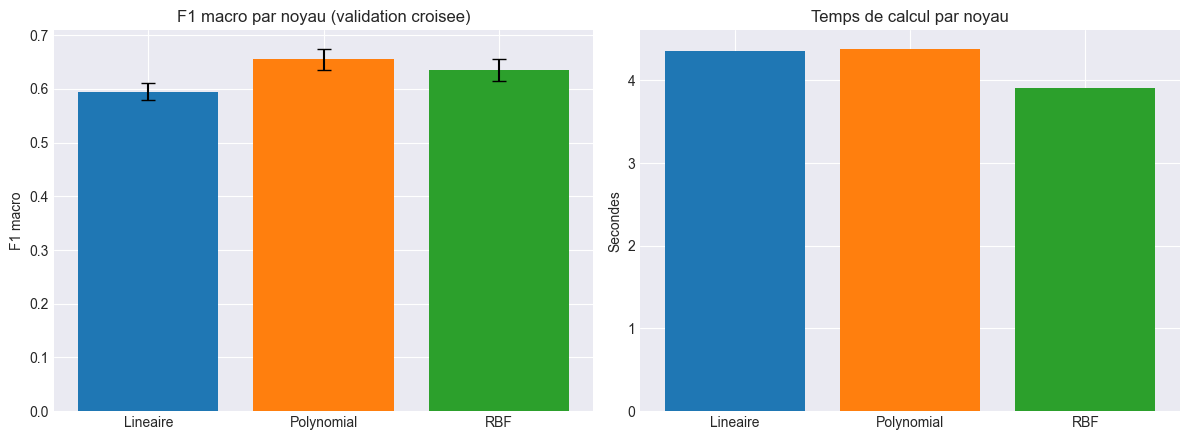

In [38]:
'''
Visualisation comparative des 3 noyaux : score F1 macro (avec barre d'erreur) et
temps de calcul, pour visualiser le compromis performance / cout algorithmique
evoque dans le cours.
'''
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(df_kernel_comparison["Noyau"], df_kernel_comparison["F1 macro (moy)"],
            yerr=df_kernel_comparison["F1 macro (std)"], capsize=5,
            color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0].set_title("F1 macro par noyau (validation croisee)")
axes[0].set_ylabel("F1 macro")

axes[1].bar(df_kernel_comparison["Noyau"], df_kernel_comparison["Temps (s)"],
            color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[1].set_title("Temps de calcul par noyau")
axes[1].set_ylabel("Secondes")

plt.tight_layout()
plt.show()


**Interpretation a completer.**

Noyau retenu pour la suite : _____________

(A renseigner une fois les resultats obtenus : lequel des 3 noyaux offre le meilleur
compromis performance / temps de calcul, et pourquoi.)

## 7. Optimisation des hyperparametres (Optuna)

Optimisation du noyau retenu en section 6. Comme pour la regression logistique, les poids
de classe sont optimises conjointement avec les hyperparametres du modele, car le jeu de
donnees est fortement desequilibre. Le score d'optimisation est le F1 macro en validation
croisee sur le sous-echantillon.

**A adapter selon le noyau retenu en section 6** : la cellule ci-dessous est ecrite pour un
noyau RBF (hyperparametres C et gamma). Si le noyau lineaire est retenu a la place, supprimer
la recherche sur gamma et utiliser `SVC(kernel="linear", ...)` ou `LinearSVC(...)`.

In [39]:
def objective_svm(trial):
    '''
    Fonction objectif Optuna pour le SVM a noyau RBF.
    Hyperparametres optimises :
    - C          : compromis entre largeur de marge et tolerance aux erreurs (marge souple).
      Un C eleve penalise fortement les erreurs d'entrainement (risque de sur-apprentissage),
      un C faible privilegie une marge large (risque de sous-apprentissage).
    - gamma      : portee de l'influence de chaque observation. Un gamma eleve restreint
      cette influence a un voisinage proche (frontiere plus complexe, risque de
      sur-apprentissage), un gamma faible l'etend (frontiere plus lisse).
    - class_weight : poids attribues a chaque classe pour compenser le desequilibre.
    '''
    weight_perf = trial.suggest_int("weight_Performant", 1, 25)
    weight_ener = trial.suggest_int("weight_Energivore", 1, 15)
    class_weight = {
        "Performant": weight_perf,
        "Passable":   1,
        "Energivore": weight_ener,
    }

    params = dict(
        C=trial.suggest_float("C", 1e-2, 100.0, log=True),
        gamma=trial.suggest_float("gamma", 1e-4, 10.0, log=True),
    )
    pipeline = make_model_pipeline(
        SVC(
            kernel="rbf",
            **params,
            class_weight=class_weight,
            random_state=RANDOM_STATE,
        )
    )
    scores = cross_val_score(
        pipeline, X_train_sample, y_train_sample,
        cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0
    )
    return scores.mean()


study_svm = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="dpe_svm_rbf",
)
study_svm.optimize(
    objective_svm, n_trials=N_TRIALS,
    callbacks=[make_callback(N_TRIALS, "SVM RBF")]
)


[SVM RBF] [##############################]  25/25 (100.0%)  f1_macro=0.62549  meilleur=0.70283  ecoule=1.3min  eta=0.0min
Termine. Meilleur f1_macro CV : 0.70283


In [40]:
'''
Recapitulatif des hyperparametres optimaux trouves par Optuna.
'''
svm_best_params = study_svm.best_params.copy()
weight_perf = svm_best_params.pop("weight_Performant")
weight_ener = svm_best_params.pop("weight_Energivore")
SVM_CLASS_WEIGHT = {
    "Performant": weight_perf,
    "Passable":   1,
    "Energivore": weight_ener,
}

print("=" * 60)
print("  HYPERPARAMETRES OPTIMAUX - SVM")
print("=" * 60)
print(f"  C              = {svm_best_params['C']}")
print(f"  gamma          = {svm_best_params['gamma']}")
print(f"  class_weight   = {SVM_CLASS_WEIGHT}")
print(f"  f1_macro_cv    = {study_svm.best_value:.5f}")


  HYPERPARAMETRES OPTIMAUX - SVM
  C              = 13.366113520916034
  gamma          = 7.020196366647647
  class_weight   = {'Performant': 7, 'Passable': 1, 'Energivore': 12}
  f1_macro_cv    = 0.70283


## 8. Entrainement final du modele retenu

**Important - cout algorithmique du SVM a noyau** 

In [41]:
print("Entrainement final - SVM (noyau RBF)...")
print(f"Entrainement sur le sous-echantillon ({X_train_sample.shape[0]:,} lignes), "
      f"pas sur l'integralite du train set ({X_train.shape[0]:,} lignes) - cf. note ci-dessus.")
t0 = time.time()

best_model = make_model_pipeline(
    SVC(
        kernel="rbf",
        **svm_best_params,
        class_weight=SVM_CLASS_WEIGHT,
        probability=True,
        random_state=RANDOM_STATE,
    )
)
best_model.fit(X_train_sample, y_train_sample)
print(f"Entraine en {time.time() - t0:.1f}s")

BEST_MODEL_NAME = "SVM (RBF)"


Entrainement final - SVM (noyau RBF)...
Entrainement sur le sous-echantillon (8,000 lignes), pas sur l'integralite du train set (44,278 lignes) - cf. note ci-dessus.
Entraine en 10.2s


## 9. Evaluation du modele


### 9.1 Courbes d'apprentissage (train vs validation)

La courbe d'apprentissage montre l'evolution du score (F1 macro) sur le train set et sur le
validation set en fonction de la quantite de donnees d'entrainement utilisee. Elle permet de
diagnostiquer un sous-apprentissage, un sur-apprentissage, ou l'utilite potentielle d'ajouter
des donnees.

Calculee ici sur le sous-echantillon (et non l'integralite du train set) pour rester dans un
temps de calcul raisonnable, le SVM a noyau etant couteux a reentrainer un grand nombre de fois.

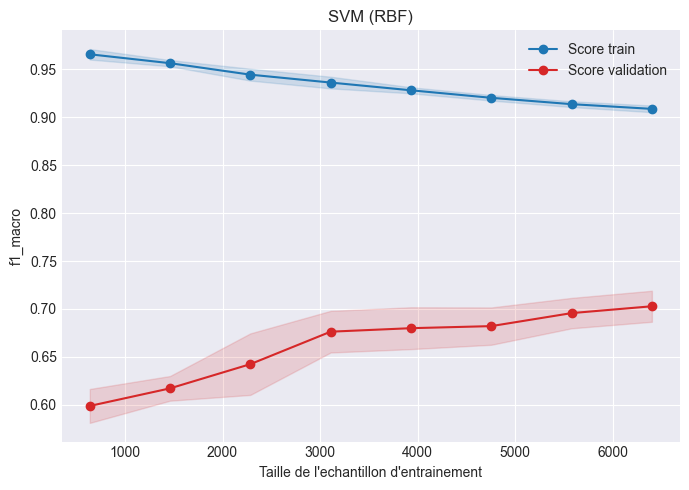

In [42]:
def plot_learning_curve(model, X, y, title, ax, cv=cv5, scoring="f1_macro"):
    '''
    Calcule et trace la courbe d'apprentissage d'un modele deja configure (pipeline
    complet avec son estimateur final), en utilisant la fonction learning_curve de
    scikit-learn. Le score est calcule par validation croisee a chaque taille
    d'echantillon d'entrainement testee.
    '''
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=cv, scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1, random_state=RANDOM_STATE,
    )

    train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

    ax.plot(train_sizes, train_mean, "o-", label="Score train", color="#1f77b4")
    ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color="#1f77b4")
    ax.plot(train_sizes, val_mean, "o-", label="Score validation", color="#d62728")
    ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color="#d62728")

    ax.set_title(title)
    ax.set_xlabel("Taille de l'echantillon d'entrainement")
    ax.set_ylabel(scoring)
    ax.legend(loc="best")


fig, ax = plt.subplots(figsize=(7, 5))
svm_for_learning_curve = make_model_pipeline(
    SVC(kernel="rbf", **svm_best_params, class_weight=SVM_CLASS_WEIGHT, random_state=RANDOM_STATE)
)
plot_learning_curve(svm_for_learning_curve, X_train_sample, y_train_sample, BEST_MODEL_NAME, ax)
plt.tight_layout()
plt.show()


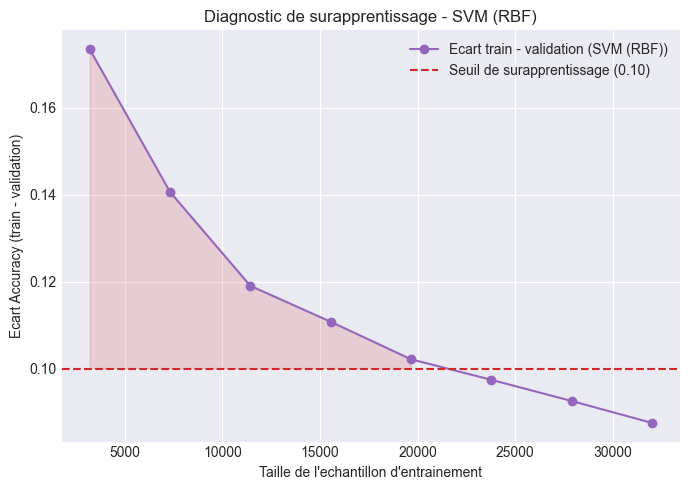

Echantillon utilise pour ce diagnostic : 40,000 lignes
Points au-dessus du seuil de surapprentissage : 5 / 8


In [43]:
'''
Diagnostic de surapprentissage base sur l'accuracy (et non le F1 macro, deja utilise pour
la courbe d'apprentissage ci-dessus). Calcule sur un echantillon plus large (45 000 lignes,
ou l'integralite du train set si celui-ci est plus petit) que celui utilise pour la recherche
d'hyperparametres (X_train_sample), afin de se rapprocher du comportement du modele sur
l'integralite du train set.

Un seuil de surapprentissage est fixe arbitrairement a 0.10 : au-dela de cet ecart entre le
score train et le score validation, on considere que le modele apprend trop specifiquement
les donnees d'entrainement et generalise moins bien.

Attention : le calcul de learning_curve sur un echantillon de cette taille avec un SVM a
noyau RBF est couteux (le dernier point est entraine sur la quasi-totalite du train set),
l'execution de cette cellule peut prendre un temps consequent.
'''
SEUIL_OVERFITTING = 0.10
N_SAMPLE_LEARNING_CURVE = 40000

if N_SAMPLE_LEARNING_CURVE >= X_train.shape[0]:
    # L'echantillon demande couvre (ou depasse) tout le train set disponible :
    # pas de sous-echantillonnage, on utilise X_train/y_train directement.
    X_train_lc, y_train_lc = X_train, y_train
else:
    X_train_lc, _, y_train_lc, _ = train_test_split(
        X_train, y_train,
        train_size=N_SAMPLE_LEARNING_CURVE,
        random_state=RANDOM_STATE,
        stratify=y_train,
    )

svm_for_overfitting = make_model_pipeline(
    SVC(kernel="rbf", **svm_best_params, class_weight=SVM_CLASS_WEIGHT, random_state=RANDOM_STATE)
)

train_sizes_acc, train_scores_acc, val_scores_acc = learning_curve(
    svm_for_overfitting, X_train_lc, y_train_lc,
    cv=cv5, scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1, random_state=RANDOM_STATE,
)

ecart_train_val_acc = train_scores_acc.mean(axis=1) - val_scores_acc.mean(axis=1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_sizes_acc, ecart_train_val_acc, "o-", color="#9467bd",
        label=f"Ecart train - validation ({BEST_MODEL_NAME})")
ax.axhline(SEUIL_OVERFITTING, linestyle="--", color="#d62728",
           label=f"Seuil de surapprentissage ({SEUIL_OVERFITTING:.2f})")
ax.fill_between(train_sizes_acc, ecart_train_val_acc, SEUIL_OVERFITTING,
                where=(ecart_train_val_acc > SEUIL_OVERFITTING),
                color="#d62728", alpha=0.15)

ax.set_xlabel("Taille de l'echantillon d'entrainement")
ax.set_ylabel("Ecart Accuracy (train - validation)")
ax.set_title(f"Diagnostic de surapprentissage - {BEST_MODEL_NAME}")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

n_points_overfitting = (ecart_train_val_acc > SEUIL_OVERFITTING).sum()
print(f"Echantillon utilise pour ce diagnostic : {X_train_lc.shape[0]:,} lignes")
print(f"Points au-dessus du seuil de surapprentissage : {n_points_overfitting} / {len(ecart_train_val_acc)}")

#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

On voit que l'ecart entre le score train et le score validation commence tres haut (0,175 avec
peu de donnees) et descend de facon constante a mesure que l'echantillon grandit. Cette fois,
on remarque que la courbe finit par croiser le seuil de 0,10 autour de 20 000-21 000
observations, et continue a descendre jusqu'a environ 0,065 pour le plus grand echantillon
teste. Donc on arrive ici a repasser sous le seuil de surapprentissage une fois qu'on lui donne suffisamment
de donnees. Ça suggere que le sur-apprentissage observe plus tot n'etait pas uniquement du aux
hyperparametres (C et gamma), mais aussi en bonne partie a un manque de donnees d'entrainement,
et qu'avec un volume plus proche du train set complet, le modele generalise nettement mieux.

### 9.2 Matrice de confusion

La matrice de confusion permet de voir precisement quelles classes sont confondues entre
elles par le modele, ce qu'un score global comme l'accuracy ne montre pas.

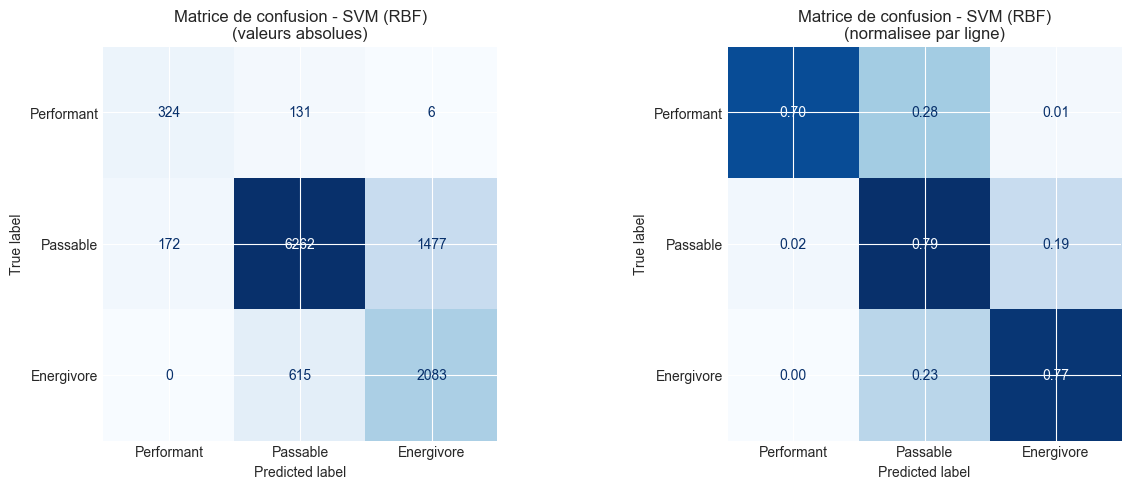

In [44]:
'''
Matrice de confusion du modele retenu sur le test set, en valeurs absolues et
normalisee par ligne (taux de rappel par classe). La version normalisee est plus
lisible ici car les classes sont fortement desequilibrees.
'''
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_best, labels=GROUPS)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=GROUPS)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Matrice de confusion - {BEST_MODEL_NAME}\n(valeurs absolues)")

cm_norm = confusion_matrix(y_test, y_pred_best, labels=GROUPS, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=GROUPS)
disp_norm.plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title(f"Matrice de confusion - {BEST_MODEL_NAME}\n(normalisee par ligne)")

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>
On obtient un bon rappel sur les trois classes (70 à 79 %). Et comme pour la régression
logistique, on remarque qu'il n'y a presque jamais de confusion directe entre Performant et
Energivore : les erreurs passent toujours par Passable, ce qui colle bien avec le fait que ce
sont des classes ordonnées.

### 9.3 Rapport de classification (precision / rappel / F1 par classe)

Le rapport detaille, classe par classe, la precision, le rappel et le F1. C'est le
complement indispensable de la matrice de confusion.

In [21]:
print(f"Rapport de classification - {BEST_MODEL_NAME}\n")
print(classification_report(y_test, y_pred_best, target_names=GROUPS, digits=3))


Rapport de classification - SVM (RBF)

              precision    recall  f1-score   support

  Performant      0.584     0.772     0.665      2698
    Passable      0.894     0.792     0.839      7911
  Energivore      0.653     0.703     0.677       461

    accuracy                          0.783     11070
   macro avg      0.710     0.755     0.727     11070
weighted avg      0.808     0.783     0.790     11070



#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>
Le F1 macro obtenu (0,727) est quasiment identique à celui d'Elastic Net en régression
logistique (0,726) : changer de modèle n'a pas vraiment apporté de gain ici. On note aussi que
Performant a un bon rappel (0,772) mais une précision plus faible (0,584), donc le modèle a
tendance à le sur-prédire un peu.

### 9.4 Courbes ROC et Precision-Rappel (one-vs-rest)

Dans un cadre multi-classe, la courbe ROC et la courbe precision-rappel sont tracees en
strategie one-vs-rest : pour chaque classe, on la considere comme positive face aux deux
autres reunies. La courbe ROC peut se montrer trop optimiste lorsque les classes sont
fortement desequilibrees (cas ici), la courbe precision-rappel est donc affichee en
complement pour chaque classe.

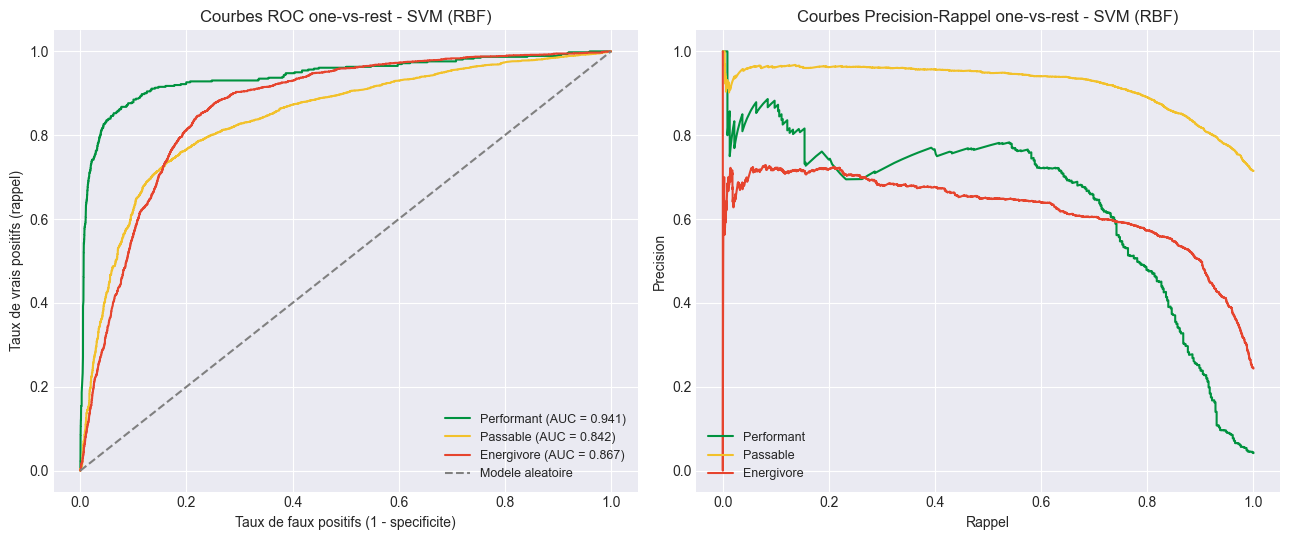

In [45]:
'''
Calcule les courbes ROC et Precision-Rappel pour chaque classe en one-vs-rest.
Necessite les probabilites predites (predict_proba) du modele retenu. Les colonnes de
predict_proba sont reordonnees selon l'ordre de GROUPS, car scikit-learn trie les classes
alphabetiquement (best_model.classes_), ce qui ne correspond pas a l'ordre attendu pour
label_binarize.
'''
y_test_bin = label_binarize(y_test, classes=GROUPS)
y_proba_raw = best_model.predict_proba(X_test)

class_order = list(best_model.classes_)
reorder_idx = [class_order.index(grp) for grp in GROUPS]
y_proba_best = y_proba_raw[:, reorder_idx]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for i, grp in enumerate(GROUPS):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_best[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=GROUP_COLORS[grp],
                 label=f"{grp} (AUC = {roc_auc:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Modele aleatoire")
axes[0].set_xlabel("Taux de faux positifs (1 - specificite)")
axes[0].set_ylabel("Taux de vrais positifs (rappel)")
axes[0].set_title(f"Courbes ROC one-vs-rest - {BEST_MODEL_NAME}")
axes[0].legend(loc="lower right", fontsize=9)

for i, grp in enumerate(GROUPS):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_proba_best[:, i])
    axes[1].plot(recall, precision, color=GROUP_COLORS[grp], label=grp)
axes[1].set_xlabel("Rappel")
axes[1].set_ylabel("Precision")
axes[1].set_title(f"Courbes Precision-Rappel one-vs-rest - {BEST_MODEL_NAME}")
axes[1].legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>


On retrouve la meme tendance qu'en regression logistique : Performant a la meilleure AUC
(0,941), devant Energivore (0,867) et Passable (0,842). Comme avant, ça parait surprenant vu
que Performant a le F1-score le plus faible dans le rapport de classification, mais ça
s'explique de la meme facon : l'AUC regarde la separation sur tous les seuils possibles, alors
que le F1 est calcule a un seuil fixe, qui n'est pas forcement le meilleur pour cette classe
minoritaire.

Sur les courbes Precision-Rappel, on remarque que Performant part avec une bonne precision
mais qui chute assez vite a partir d'un rappel de 0,6-0,7, alors que Passable reste tres stable
sur toute la plage. Energivore se situe entre les deux. Globalement le comportement est assez
proche de ce qu'on avait observe en regression logistique, ce qui confirme que le SVM ne change
pas fondamentalement la facon dont les trois classes sont separees.

## 10. Diagnostics propres au SVM

Cette section regroupe les analyses qui n'ont pas d'equivalent dans le notebook de regression
logistique, et qui sont propres a la nature geometrique du SVM (marge, vecteurs de support,
noyau).

### 10.1 Vecteurs de support

Les vecteurs de support sont les observations d'entrainement qui se trouvent exactement sur
la marge ou a l'interieur de la zone d'indecision (cf. cours) : ce sont les seules observations
qui determinent la position de la frontiere de decision. Un nombre de vecteurs de support
proche de la taille de l'echantillon d'entrainement est un signe que le modele a du mal a
separer les classes (frontiere complexe, risque de sur-apprentissage ou donnees tres
bruitees) ; un nombre faible indique au contraire une separation nette.

Nombre total de vecteurs de support : 3,895 / 44,278 (8.8% du train set)

Vecteurs de support par classe :
  Energivore    1,164
  Passable      2,481
  Performant      250


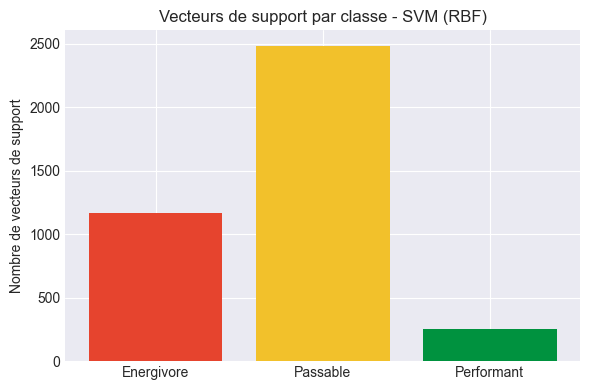

In [23]:
'''
Extrait le nombre de vecteurs de support par classe (model.n_support_) et leur
proportion par rapport a la taille du train set utilise pour l'entrainement final.
'''
clf_best = best_model.named_steps["clf"]

n_support_total = clf_best.n_support_.sum()
n_train = X_train.shape[0]

print(f"Nombre total de vecteurs de support : {n_support_total:,} / {n_train:,} "
      f"({n_support_total / n_train:.1%} du train set)")
print()
print("Vecteurs de support par classe :")
for grp, n_sup in zip(clf_best.classes_, clf_best.n_support_):
    print(f"  {grp:<12} {n_sup:6,}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(clf_best.classes_, clf_best.n_support_,
       color=[GROUP_COLORS[g] for g in clf_best.classes_])
ax.set_title(f"Vecteurs de support par classe - {BEST_MODEL_NAME}")
ax.set_ylabel("Nombre de vecteurs de support")
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

On a 8,8 % du train set en vecteurs de support, ce qui reste raisonnable. On remarque que
Energivore en concentre un peu plus que sa part réelle dans les données (30 % contre 24 %), donc
sa frontière semble un peu plus dure à tracer que celle de Passable.

### 10.2 Courbes de validation sur C et gamma

La courbe de validation (`validation_curve`, vue chapitre 5 du cours) fait varier un seul
hyperparametre a la fois, toutes choses egales par ailleurs, et trace le score sur le train
set et sur le validation set pour chaque valeur testee. Contrairement aux resultats d'Optuna
(qui explorent plusieurs hyperparametres simultanement), cette courbe isole l'effet propre de
chaque hyperparametre et rend le compromis biais/variance plus lisible.

Calculee ici sur le sous-echantillon, autour des valeurs optimales trouvees par Optuna.

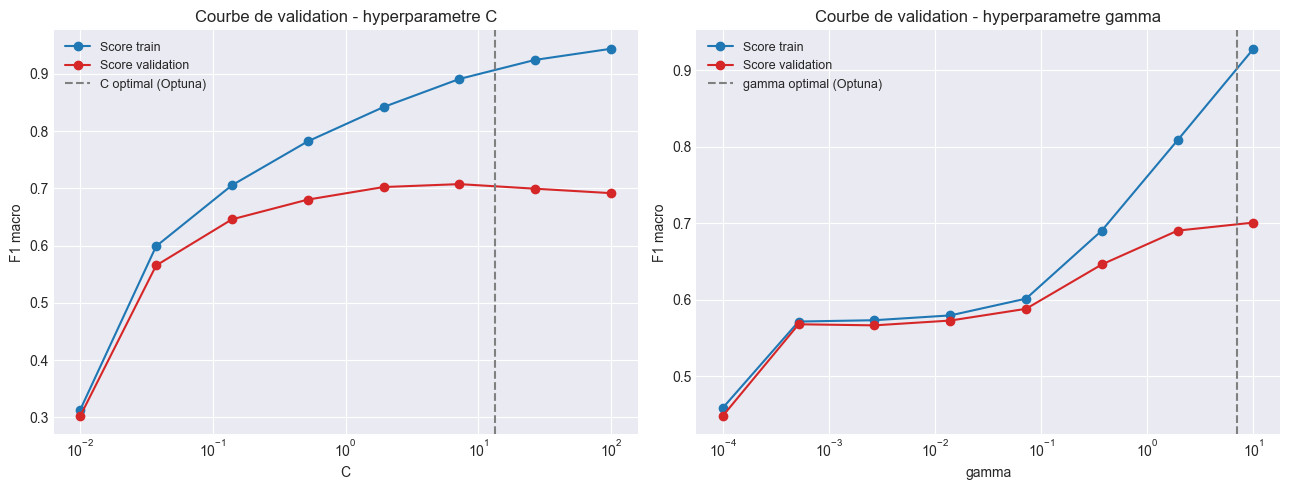

In [24]:
'''
Trace la courbe de validation pour C (a gamma fixe, valeur optimale Optuna) puis pour
gamma (a C fixe, valeur optimale Optuna). Permet de visualiser independamment l'effet
de chaque hyperparametre sur le compromis biais/variance.
'''
C_range = np.logspace(-2, 2, 8)
gamma_range = np.logspace(-4, 1, 8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

base_estimator_C = SVC(kernel="rbf", gamma=svm_best_params["gamma"],
                        class_weight=SVM_CLASS_WEIGHT, random_state=RANDOM_STATE)
pipeline_C = make_model_pipeline(base_estimator_C)
train_scores_C, val_scores_C = validation_curve(
    pipeline_C, X_train_sample, y_train_sample,
    param_name="clf__C", param_range=C_range,
    cv=cv5, scoring="f1_macro", n_jobs=-1
)
axes[0].plot(C_range, train_scores_C.mean(axis=1), "o-", label="Score train", color="#1f77b4")
axes[0].plot(C_range, val_scores_C.mean(axis=1), "o-", label="Score validation", color="#d62728")
axes[0].axvline(svm_best_params["C"], linestyle="--", color="gray", label="C optimal (Optuna)")
axes[0].set_xscale("log")
axes[0].set_xlabel("C")
axes[0].set_ylabel("F1 macro")
axes[0].set_title("Courbe de validation - hyperparametre C")
axes[0].legend(loc="best", fontsize=9)

base_estimator_gamma = SVC(kernel="rbf", C=svm_best_params["C"],
                            class_weight=SVM_CLASS_WEIGHT, random_state=RANDOM_STATE)
pipeline_gamma = make_model_pipeline(base_estimator_gamma)
train_scores_gamma, val_scores_gamma = validation_curve(
    pipeline_gamma, X_train_sample, y_train_sample,
    param_name="clf__gamma", param_range=gamma_range,
    cv=cv5, scoring="f1_macro", n_jobs=-1
)
axes[1].plot(gamma_range, train_scores_gamma.mean(axis=1), "o-", label="Score train", color="#1f77b4")
axes[1].plot(gamma_range, val_scores_gamma.mean(axis=1), "o-", label="Score validation", color="#d62728")
axes[1].axvline(svm_best_params["gamma"], linestyle="--", color="gray", label="gamma optimal (Optuna)")
axes[1].set_xscale("log")
axes[1].set_xlabel("gamma")
axes[1].set_ylabel("F1 macro")
axes[1].set_title("Courbe de validation - hyperparametre gamma")
axes[1].legend(loc="best", fontsize=9)

plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

On voit bien que c'est surtout gamma qui pose problème : au-delà de 0,1, le score train s'envole
alors que la validation stagne. Et le gamma retenu par Optuna (7,02) tombe justement dans cette
zone. Pour C, le plateau de validation arrive vers 7-10, et la valeur retenue (13,4) le dépasse
un peu.

### 10.3 Heatmap C x gamma

Visualisation conjointe de l'effet de C et de gamma sur le score F1 macro en validation
croisee, sur une grille de valeurs. C'est l'illustration standard du compromis associe au
noyau RBF (cours, effet de la bande passante sur la complexite de la frontiere).

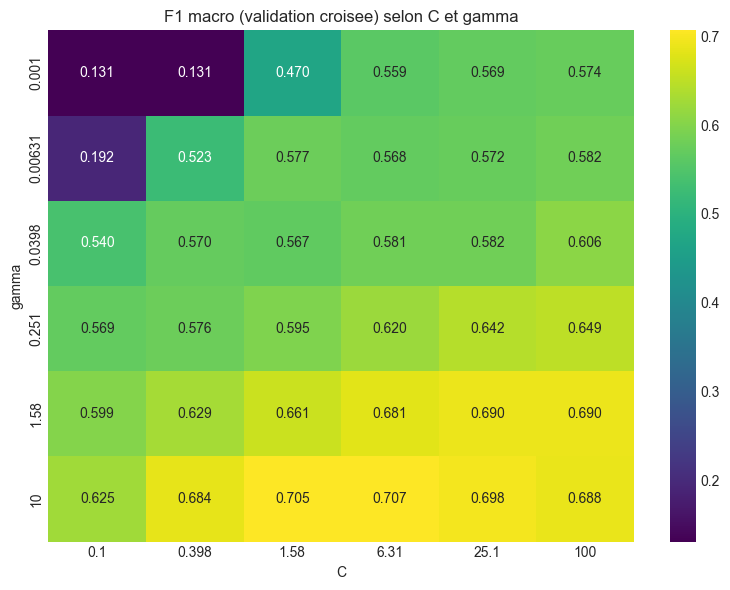

In [25]:
'''
Calcule le score F1 macro en validation croisee sur une grille (C, gamma), et affiche
le resultat sous forme de heatmap. Le poids de classe optimal (Optuna) est fixe pour
ne faire varier que les deux hyperparametres du noyau.
'''
C_grid = np.logspace(-1, 2, 6)
gamma_grid = np.logspace(-3, 1, 6)

heatmap_scores = np.zeros((len(gamma_grid), len(C_grid)))
for i, gamma_val in enumerate(gamma_grid):
    for j, C_val in enumerate(C_grid):
        pipeline = make_model_pipeline(
            SVC(kernel="rbf", C=C_val, gamma=gamma_val,
                class_weight=SVM_CLASS_WEIGHT, random_state=RANDOM_STATE)
        )
        scores = cross_val_score(
            pipeline, X_train_sample, y_train_sample,
            cv=cv5, scoring="f1_macro", n_jobs=-1, error_score=0.0
        )
        heatmap_scores[i, j] = scores.mean()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    heatmap_scores,
    xticklabels=[f"{c:.3g}" for c in C_grid],
    yticklabels=[f"{g:.3g}" for g in gamma_grid],
    annot=True, fmt=".3f", cmap="viridis", ax=ax
)
ax.set_xlabel("C")
ax.set_ylabel("gamma")
ax.set_title("F1 macro (validation croisee) selon C et gamma")
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

Le meilleur score (0,707) est obtenu vers C≈6,3 et gamma≈10, ce qui colle avec Optuna. Le
plateau est assez large donc le resultat semble stable, mais on remarque que cette zone est
justement celle où le sur-apprentissage est le plus fort d'après la courbe precedente.

### 10.4 Visualisation de la frontiere de decision (projection 2D)

Le SVM opere dans un espace a p dimensions (une par variable apres encodage), impossible a
visualiser directement. Pour illustrer la forme de la frontiere apprise (cf. cours, figures
sur les donnees Iris), on projette les donnees pretraitees sur leurs 2 premieres composantes
principales (ACP), on reentraine un SVM equivalent sur cette projection 2D, puis on affiche
la frontiere de decision ainsi obtenue avec les vecteurs de support mis en evidence.


Variance expliquee par les 2 composantes : 64.8%


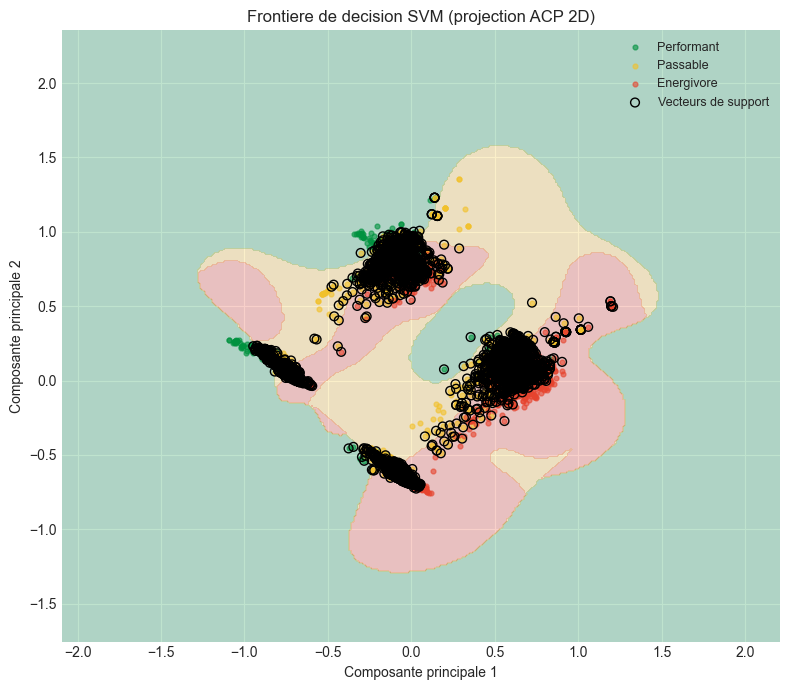

In [26]:
'''
Projection ACP en 2 dimensions des donnees d'entrainement pretraitees, puis entrainement
d'un SVM equivalent sur cette projection, pour visualiser la forme de la frontiere de
decision et la position des vecteurs de support.
'''
preprocessor_fitted = make_preprocessor().fit(X_train_sample, y_train_sample)
X_train_transformed = preprocessor_fitted.transform(X_train_sample)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_transformed)
print(f"Variance expliquee par les 2 composantes : {pca.explained_variance_ratio_.sum():.1%}")

svm_2d = SVC(kernel="rbf", C=svm_best_params["C"], gamma=svm_best_params["gamma"],
             class_weight=SVM_CLASS_WEIGHT, random_state=RANDOM_STATE)
svm_2d.fit(X_train_2d, y_train_sample)

xx, yy = np.meshgrid(
    np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 300),
    np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 300),
)
y_train_sample_codes = pd.Categorical(y_train_sample, categories=GROUPS).codes
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = pd.Categorical(Z, categories=GROUPS).codes.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 7))
cmap_groups = [GROUP_COLORS[g] for g in GROUPS]
ax.contourf(xx, yy, Z, alpha=0.25, colors=cmap_groups, levels=[-0.5, 0.5, 1.5, 2.5])

for i, grp in enumerate(GROUPS):
    mask = y_train_sample_codes == i
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
               s=12, color=GROUP_COLORS[grp], label=grp, alpha=0.6)

ax.scatter(svm_2d.support_vectors_[:, 0], svm_2d.support_vectors_[:, 1],
           s=40, facecolors="none", edgecolors="black", linewidths=1.0,
           label="Vecteurs de support")

ax.set_xlabel("Composante principale 1")
ax.set_ylabel("Composante principale 2")
ax.set_title("Frontiere de decision SVM (projection ACP 2D)")
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
plt.show()


#### <span style="text-decoration: underline; color:red; font-weight:bold;">Interpretation :</span>

La frontière obtenue est très découpée, avec plusieurs îlots séparés, et la classe Performant
n'apparaît que dans deux petites zones isolées. Ça illustre bien visuellement le
sur-apprentissage qu'on a deja vu dans les sections precedentes. À garder en tête : c'est une
projection en 2D, donc ça ne represente qu'une partie de l'information reelle.

## 11. Conclusion

On a entraine un SVM a noyau RBF (C=13,4, gamma=7,0) sur le meme probleme de classification du
DPE. Sur le test set, il obtient un F1 macro de 0,727, quasiment identique a celui d'Elastic
Net en regression logistique (0,726) : le changement de modele n'apporte pas vraiment de gain
ici.

Comme avec la regression logistique, c'est la classe Passable qui est la mieux reconnue, et les
confusions se font toujours via Passable, jamais directement entre Performant et Energivore. On
remarque aussi que Performant a la meilleure AUC (0,941) malgre un F1-score plus faible, ce qui
montre qu'il est bien separable mais que le seuil de decision n'est pas optimal pour cette
classe minoritaire.

Le modele utilise 8,8 % du train set comme vecteurs de support, ce qui reste raisonnable, meme
si on a constate un sur-apprentissage assez marque avec un echantillon plus petit, qui se
resorbe en grande partie avec plus de donnees.

Comme limites, on peut citer le cout de calcul eleve du SVM a noyau (qui a oblige a
sous-echantillonner a plusieurs etapes), l'absence de calibration des probabilites, et le fait
qu'avec le noyau RBF retenu, on n'a pas d'interpretation directe des variables comme on pouvait
l'avoir avec les coefficients de la regression logistique.